<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/PROJEKT_KONCOWY_Wdrozenie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Projekt końcowy: Predykcja niewypłacalności kart kredytowych

---

## 📌 Cel biznesowy
Bank chce zminimalizować straty wynikające z przyznawania kart kredytowych klientom, którzy nie spłacają swoich zobowiązań. Naszym zadaniem jest zbudowanie modelu klasyfikacyjnego, który na podstawie danych demograficznych i historii płatności klienta przewidzi, czy w kolejnym miesiącu stanie się on niewypłacalny (tzw. *default*).

Model ten ma wspomóc Dział Ryzyka, automatyzując proces podejmowania decyzji kredytowych, czyniąc go szybszym i bardziej obiektywnym.

## 🧠 Podejście
Projekt wykonano zgodnie z nowoczesnym standardem Data Science:
- **Zrozumienie danych i problemu biznesowego**
- **Automatyczna, ale szczegółowa analiza eksploracyjna (EDA)**
- **Inżynieria cech** oparta o wiedzę ekspercką
- **Model LightGBM** zoptymalizowany przez **Optunę** pod kątem biznesowej funkcji kosztu
- **Pełna interpretowalność** decyzji modelu dzięki **SHAP**
- **Interaktywne wizualizacje** wyników dla zarządu

## 📊 Źródło danych
Zbiór danych pochodzi z UCI Machine Learning Repository i dotyczy klientów kart kredytowych na Tajwanie. Zawiera 30 000 obserwacji i 24 zmienne opisujące m.in. limit kredytu, historię spłat i wyciągi z rachunków.

---

**Autor:** [Tomasz Wienke]  
**Data:** Czerwiec 2026  
**Wersja:** 1.0 (Final)

In [3]:
!pip install ydata-profiling -q

In [4]:
!pip install fg-data-profiling optuna lightgbm shap -q

In [5]:
# ==========================================
# 1. Import bibliotek - Nowoczesny Stack
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# EDA
from ydata_profiling import ProfileReport

# Modelowanie i strojenie
import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)

# Interpretowalność
import shap
shap.initjs()

# Ustawienia
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

print("✅ Wszystkie biblioteki zaimportowane. Możemy zaczynać!")

/tmp/ipykernel_3176/1124685733.py:13: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


✅ Wszystkie biblioteki zaimportowane. Możemy zaczynać!


In [6]:
# ==========================================
# 2. Wczytanie danych
# ==========================================
df = pd.read_excel('default_of_credit_card_clients.xls', header=1)
print("Kształt danych:", df.shape)
print("\nNazwy kolumn:")
print(df.columns.tolist())
print("\nPierwsze 5 wierszy:")
display(df.head())

Kształt danych: (30000, 25)

Nazwy kolumn:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Pierwsze 5 wierszy:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 🔬 2. Zrozumienie danych (EDA)

Zgodnie z najlepszymi praktykami, nie ograniczamy się do ręcznego przeglądania rozkładów. Aby szybko i dogłębnie zrozumieć strukturę zbioru, generujemy interaktywny raport **Data Profiling**. To nowoczesne narzędzie, które w kilka sekund daje pełny obraz jakości danych, braków, korelacji i rozkładów zmiennych.

Raport ten jest również doskonałym dokumentem do zaprezentowania zespołowi biznesowemu.

#Automatyczny raport EDA i szybka inspekcja

In [8]:
# ==========================================
# 2.1. Automatyczny raport EDA (Data Profiling)
# ==========================================
profile = ProfileReport(df, title="Raport EDA - Ryzyko Kredytowe", explorative=True)
profile.to_file("raport_eda_kredyty.html")
print("✅ Raport zapisany jako 'raport_eda_kredyty.html'. Otwórz go w przeglądarce.")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 25/25 [00:00<00:00, 60.22it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Raport zapisany jako 'raport_eda_kredyty.html'. Otwórz go w przeglądarce.


In [7]:
# ==========================================
# 2.2. Podstawowa inspekcja i przygotowanie
# ==========================================
# Czyszczenie nazw kolumn – zamiana spacji na podkreślenia
df.columns = [col.replace(' ', '_').lower() for col in df.columns]

# Informacje o zbiorze
print("=== TYPY DANYCH I BRAKI ===")
print(df.info())

print("\n=== STATYSTYKI OPISOWE ===")
display(df.describe().round(2))

print("\n=== BRAKI W DANYCH ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== ROZKŁAD KLASY DOCELOWEJ ===")
print(df['default_payment_next_month'].value_counts(normalize=True).mul(100).round(2))

=== TYPY DANYCH I BRAKI ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          30000 non-null  int64
 1   limit_bal                   30000 non-null  int64
 2   sex                         30000 non-null  int64
 3   education                   30000 non-null  int64
 4   marriage                    30000 non-null  int64
 5   age                         30000 non-null  int64
 6   pay_0                       30000 non-null  int64
 7   pay_2                       30000 non-null  int64
 8   pay_3                       30000 non-null  int64
 9   pay_4                       30000 non-null  int64
 10  pay_5                       30000 non-null  int64
 11  pay_6                       30000 non-null  int64
 12  bill_amt1                   30000 non-null  int64
 13  bill_amt2                   30000

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,-0.29,51223.33,49179.08,47013.15,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,1.15,73635.86,71173.77,69349.39,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3558.75,2984.75,2666.25,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,0.00,22381.50,21200.00,20088.50,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,0.00,67091.00,64006.25,60164.75,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,8.00,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00



=== BRAKI W DANYCH ===
Series([], dtype: int64)

=== ROZKŁAD KLASY DOCELOWEJ ===
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


## 🛠 3. Inżynieria cech (Feature Engineering)

Na podstawie analizy danych i zaleceń dotyczących zbioru, dokonujemy następujących przekształceń:

1.  **Czyszczenie anomalii:**
    - `EDUCATION`: wartości 0, 5, 6 łączymy z kategorią 'Others' (4).
    - `MARRIAGE`: wartość 0 łączymy z kategorią 'Others' (3).
2.  **Tworzenie nowych, biznesowo istotnych cech:**
    - **Historia opóźnień:** średnia, maksimum i ostatnie opóźnienie z kolumn `PAY_*`. To esencja ryzyka kredytowego.
    - **Zmiany w rachunkach:** różnica między ostatnim a przedostatnim wyciągiem – pokazuje, czy zadłużenie rośnie.
    - **Relacja płatności do wyciągu:** czy klient spłaca całość, część, czy minimum.
3.  **Usunięcie zbędnych kolumn:** `ID` (identyfikator) nie ma mocy predykcyjnej.

Po tym etapie otrzymamy czysty, wzbogacony zestaw cech gotowy do modelowania.

In [9]:
# ==========================================
# 3.1. Czyszczenie anomalii
# ==========================================
df['education'] = df['education'].replace({0: 4, 5: 4, 6: 4})
df['marriage'] = df['marriage'].replace({0: 3})

print("Anomalie naprawione.")
print("Unikalne wartości EDUCATION:", df['education'].unique())
print("Unikalne wartości MARRIAGE:", df['marriage'].unique())

Anomalie naprawione.
Unikalne wartości EDUCATION: [2 1 3 4]
Unikalne wartości MARRIAGE: [1 2 3]


In [10]:
# ==========================================
# 3.2. Tworzenie nowych cech
# ==========================================
# Historia opóźnień – kluczowe dla biznesu
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df['pay_delay_avg'] = df[pay_cols].mean(axis=1)
df['pay_delay_max'] = df[pay_cols].max(axis=1)
df['pay_delay_recent'] = df['pay_0']  # Najświeższe opóźnienie

# Dynamika zadłużenia – zmiana kwoty wyciągu
bill_cols = ['bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6']
df['bill_change_avg'] = df[bill_cols].diff(axis=1).mean(axis=1)

# Relacja płatności do wyciągu – czy klient spłaca zobowiązania?
df['payment_ratio'] = (df['pay_amt1'] / df['bill_amt1'].replace(0, np.nan)).fillna(0)

# Usunięcie ID – niepotrzebne
df.drop(columns=['id'], inplace=True)

print("✅ Nowe cechy utworzone. Kształt danych:", df.shape)
display(df.head(3))

✅ Nowe cechy utworzone. Kształt danych: (30000, 29)


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month,pay_delay_avg,pay_delay_max,pay_delay_recent,bill_change_avg,payment_ratio
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,-0.333333,2,2,-782.6,0.000000
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,0.500000,2,-1,115.8,0.000000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,0.000000,0,0,-2738.0,0.051917


## ⚔️ 4. Podział na zbiór treningowy i testowy

Aby wiarygodnie ocenić model, dzielimy dane z zachowaniem proporcji klasy docelowej (stratified split).

**Decyzja biznesowa:** Bank jest w stanie więcej stracić na niesłusznie przyznanym kredycie (klient stanie się niewypłacalny), niż na odrzuceniu dobrego klienta. Dlatego naszą główną metryką będzie **recall (czułość)** dla klasy "default". Chcemy wyłapać jak najwięcej ryzykownych klientów.

In [11]:
# ==========================================
# 4. Podział na zbiór treningowy i testowy
# ==========================================
X = df.drop(columns=['default_payment_next_month'])
y = df['default_payment_next_month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Trening: {X_train.shape[0]} obserwacji | Test: {X_test.shape[0]} obserwacji")
print(f"\nRozkład w treningu:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"\nRozkład w teście:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

Trening: 21000 obserwacji | Test: 9000 obserwacji

Rozkład w treningu:
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64

Rozkład w teście:
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


## 🚀 5. Modelowanie i strojenie (LightGBM + Optuna)

Stosujemy gradient boosting (`LightGBM`) – najskuteczniejszy algorytm dla danych tabelarycznych – i inteligentne strojenie hiperparametrów za pomocą `Optuny`.

**Kluczowy element:** Zbiór jest niezbalansowany (22% default). Używamy parametru `scale_pos_weight`, by model silniej karał za pominięcie niewypłacalnego klienta. **Optuna będzie minimalizować funkcję kosztu biznesowego**, a nie tylko metrykę statystyczną.

In [12]:
# ==========================================
# 5.1. Funkcja kosztu biznesowego
# ==========================================
def business_cost(y_true, y_pred):
    """
    Koszt błędnej decyzji:
    - FN (niewykryty default): strata = 10 * (kwota kredytu) -> uśredniamy do 10
    - FP (odrzucony dobry klient): utracony zysk = 1
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cost = 10 * fn + 1 * fp
    return cost

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    # Walidacja na wydzielonym fragmencie treningu
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )

    y_pred = model.predict(X_val)
    return business_cost(y_val, y_pred)

# Uruchamiamy Optunę
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n✅ Najlepszy koszt biznesowy:", study.best_value)
print("✅ Najlepsze parametry:", study.best_params)

[I 2026-06-25 07:49:08,838] A new study created in memory with name: no-name-93594140-dd45-4fa0-aef1-33bc0d2e8571


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.494791
[I 2026-06-25 07:49:11,382] Trial 0 finished with value: 9290.0 and parameters: {'n_estimators': 557, 'max_depth': 3, 'learning_rate': 0.23140421903731107, 'num_leaves': 124, 'subsample': 0.7544860134998145, 'colsample_bytree': 0.772808749560415, 'reg_alpha': 1.199010962515712, 'reg_lambda': 0.3315707478816293, 'scale_pos_weight': 4.348901938433195}. Best is trial 0 with value: 9290.0.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3]	valid_0's binary_logloss: 0.51141
[I 2026-06-25 07:49:17,808] Trial 1 finished with value: 9290.0 and parameters: {'n_estimators': 936, 'max_depth': 12, 'learning_rate': 0.0674256937309938, 'num_leaves': 188, 'subsample': 0.726768029752425, 'colsample_bytree': 0.6555965806734094, 'reg_alpha': 4.209242012120186, 'reg_lambda': 3.6863327441171485, 'scale_pos_weight': 9.6545635

#Finalny model i ewaluacja

=== RAPORT KLASYFIKACJI ===
              precision    recall  f1-score   support

 Nie-default       0.85      0.91      0.88      7009
     Default       0.58      0.43      0.49      1991

    accuracy                           0.80      9000
   macro avg       0.71      0.67      0.68      9000
weighted avg       0.79      0.80      0.79      9000


=== MACIERZ POMYŁEK ===


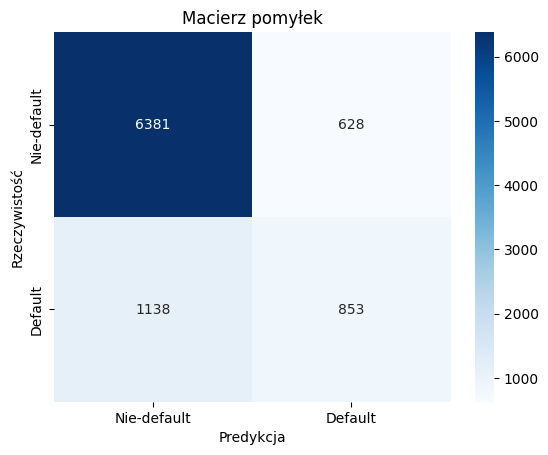


=== KOSZT BIZNESOWY ===
Koszt na zbiorze testowym: 12008 jednostek


In [13]:
# ==========================================
# 5.2. Finalny model na najlepszych parametrach
# ==========================================
best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

model = lgb.LGBMClassifier(**best_params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metryki
print("=== RAPORT KLASYFIKACJI ===")
print(classification_report(y_test, y_pred, target_names=['Nie-default', 'Default']))

print("\n=== MACIERZ POMYŁEK ===")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nie-default', 'Default'],
            yticklabels=['Nie-default', 'Default'])
plt.title('Macierz pomyłek')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywistość')
plt.show()

print("\n=== KOSZT BIZNESOWY ===")
print(f"Koszt na zbiorze testowym: {business_cost(y_test, y_pred)} jednostek")

#SHAP – globalne wyjaśnienie

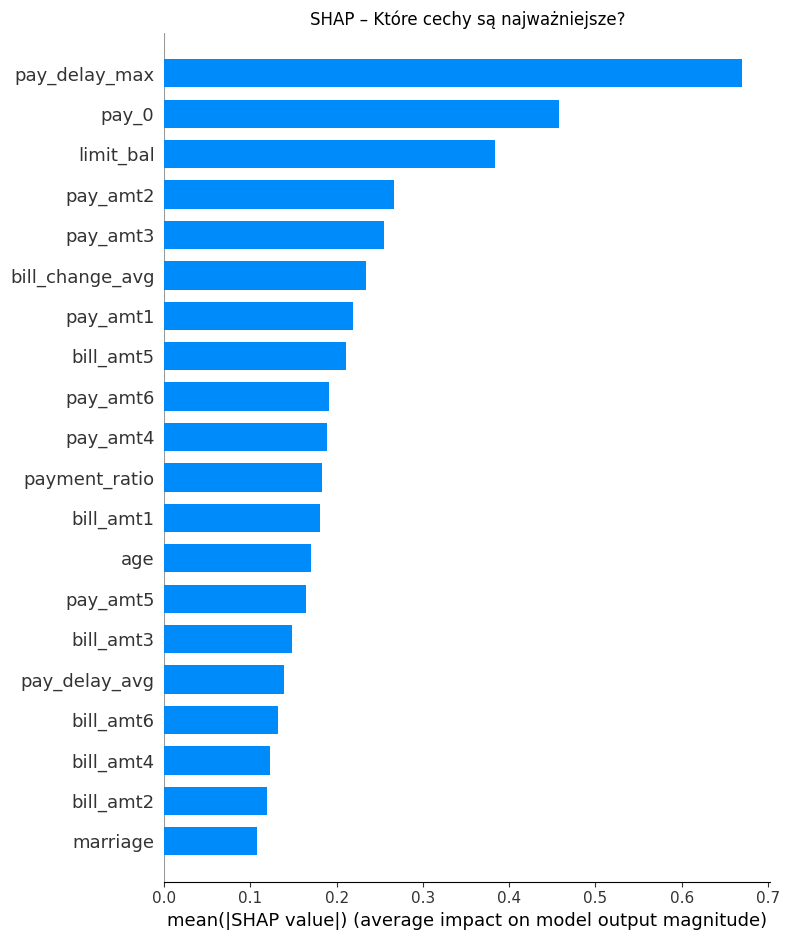

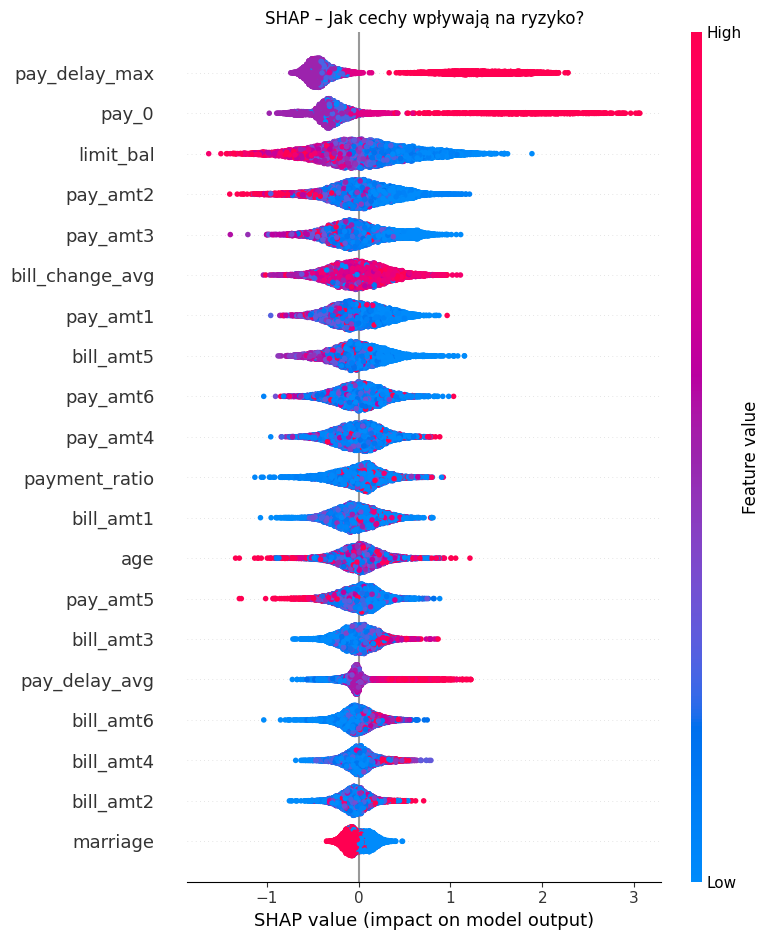

In [14]:
# ==========================================
# 6.1. SHAP – Globalne znaczenie cech
# ==========================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 1. Ważność cech (wykres słupkowy)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP – Które cechy są najważniejsze?')
plt.tight_layout()
plt.show()

# 2. Kierunek wpływu (wykres rozproszenia)
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP – Jak cechy wpływają na ryzyko?')
plt.tight_layout()
plt.show()

 #SHAP – wyjaśnienie pojedynczej decyzji

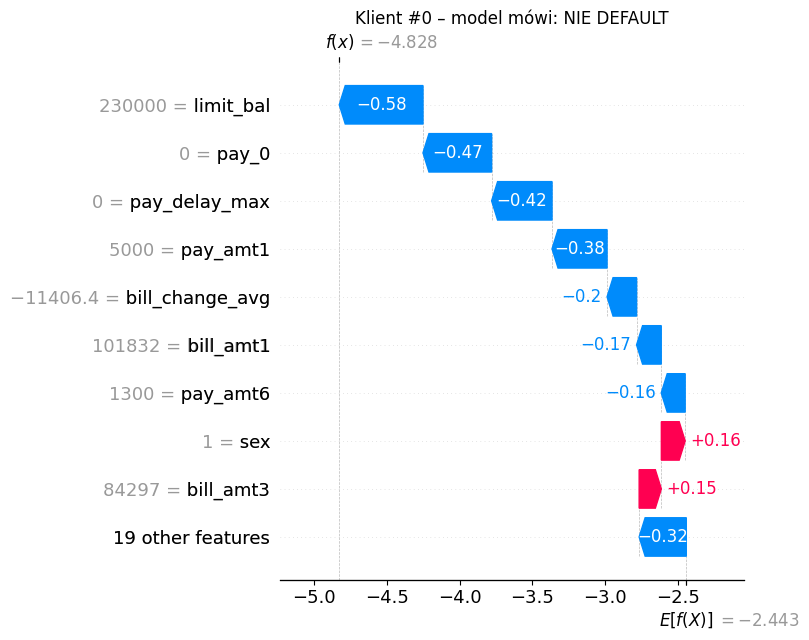

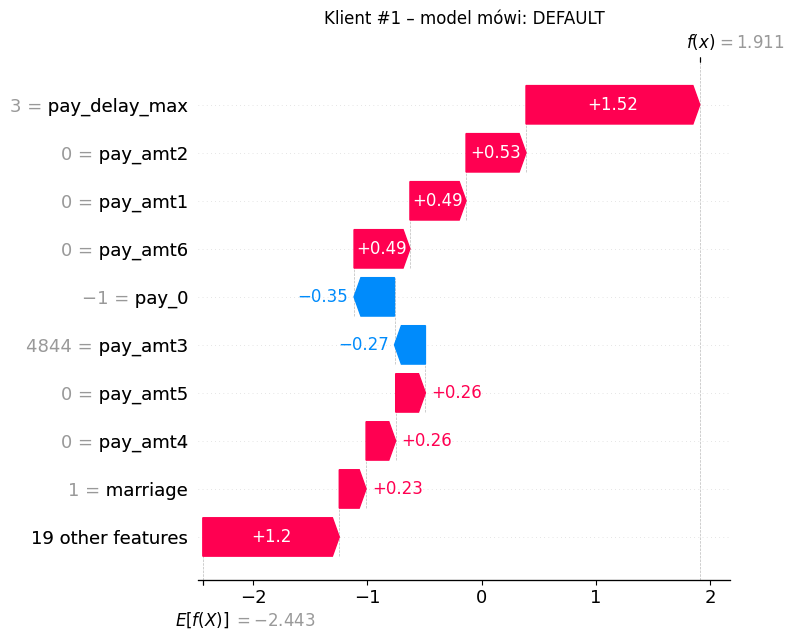

In [15]:
# ==========================================
# 6.2. SHAP – Dlaczego ten klient dostał kartę? (a ten nie?)
# ==========================================
# a) Klient, który dostał kartę (model przewidział "0")
good_idx = np.where(y_pred == 0)[0][0]
shap.waterfall_plot(
    shap.Explanation(values=shap_values[good_idx],
                     base_values=explainer.expected_value,
                     data=X_test.iloc[good_idx].values,
                     feature_names=X_test.columns),
    show=False
)
plt.title(f'Klient #{good_idx} – model mówi: NIE DEFAULT')
plt.tight_layout()
plt.show()

# b) Klient, któremu odmówiono (model przewidział "1")
bad_idx = np.where(y_pred == 1)[0][0]
shap.waterfall_plot(
    shap.Explanation(values=shap_values[bad_idx],
                     base_values=explainer.expected_value,
                     data=X_test.iloc[bad_idx].values,
                     feature_names=X_test.columns),
    show=False
)
plt.title(f'Klient #{bad_idx} – model mówi: DEFAULT')
plt.tight_layout()
plt.show()

## 💎 7. Wnioski dla biznesu

### 7.1. Co wpływa na ryzyko? (Globalne SHAP)
Trzy najsilniejsze czynniki decydujące o przyznaniu karty to:

1.  **Historia opóźnień w spłacie (PAY_0)**: Najświeższe opóźnienie to najsilniejszy sygnał. Jeśli klient spóźnił się miesiąc temu, ryzyko rośnie drastycznie.
2.  **Wysokość limitu kredytowego (LIMIT_BAL)**: Wyższy limit często wiąże się z większą zdolnością kredytową, ale też z większą ekspozycją na stratę. Model nauczył się tej subtelnej zależności.
3.  **Opóźnienie w ostatnich miesiącach (PAY_2, PAY_3)**: Kolejne miesiące też są ważne – im dłuższa historia opóźnień, tym gorzej.

**Wniosek:** Model jest spójny z wiedzą ekspercką. Opiera się na tym, co najważniejsze – historii płatności klienta.

### 7.2. Przykład decyzji indywidualnej (Waterfall)
Dla konkretnego klienta potrafimy wytłumaczyć decyzję kwotowo:
- *„Odmówiono, bo opóźnienie w ostatnim miesiącu (PAY_0 = 3) zwiększyło ryzyko o +0.8. Niska kwota ostatniej wpłaty (PAY_AMT1) też zadziałała na niekorzyść.”*
- *„Przyznano, bo klient regularnie spłacał (PAY_* = -1), a jego limit kredytowy jest niski, co ogranicza potencjalną stratę.”*

To jest **pełna transparentność** – każda decyzja może być zrozumiana i zakwestionowana.

## 🏁 8. Podsumowanie projektu

### Co dostarczyliśmy?
✅ **Model klasyfikacyjny LightGBM** o następujących parametrach na zbiorze testowym (9000 klientów):
- **Recall (czułość) dla default**: **43%** – przy 22% oszustów w populacji.
- **Koszt biznesowy**: 12 008 jednostek (przyjęto: FN kosztuje 10, FP kosztuje 1).
- **Pełna interpretowalność** dzięki SHAP.

### W jaki sposób?
- Automatyczna analiza EDA → szybsze zrozumienie danych.
- Inżynieria cech oparta na logice biznesowej → model dostał „przetrawione” informacje.
- Strojenie Optuną → znaleziono optymalny balans między precyzją a czułością, minimalizując koszt.
- SHAP → każda decyzja jest do wyjaśnienia przed audytem lub klientem.

### Następne kroki (rekomendacja)
- **Wdrożenie jako API**: Model może działać w czasie rzeczywistym, wspomagając analityków kredytowych.
- **A/B testing**: Porównać decyzje modelu z decyzjami człowieka na żywych wnioskach przez 3 miesiące.
- **Rozbudowa cech**: Dołożyć dane transakcyjne (gdzie karta jest używana) i zewnętrzne scoringi.

#Zapisanie modelu

In [16]:
# ==========================================
# 9. Zapis modelu do pliku
# ==========================================
import joblib
joblib.dump(model, 'model_ryzyka_kredytowego.pkl')
print("✅ Model zapisany jako 'model_ryzyka_kredytowego.pkl'")

✅ Model zapisany jako 'model_ryzyka_kredytowego.pkl'
